### Imports and load dataset

In [5]:
# Imports and load dataset

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report


### Data Inspection Phase

In [6]:
DATA_FILENAME = 'Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_FILENAME)

print('\n---- First 10 rows ----')
print(df.head(10))

print('\n---- Column names ----')
print(df.columns.tolist())

print('\n---- Data types ----')
print(df.dtypes)


---- First 10 rows ----
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone servic

### Data Preprocessing Phase

In [7]:
# Convert TotalCharges to numeric
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
# Remove rows with missing values
print('\nMissing values before drop:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.dropna().reset_index(drop=True)

print('\nMissing values after drop:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values before drop:
TotalCharges    11
dtype: int64

Missing values after drop:
Series([], dtype: int64)


In [9]:
# Remove customerID column if present
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

In [10]:
# Convert Churn to binary numeric: Yes -> 1, No -> 0
if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [11]:
# Convert categorical variables into dummy variables
# I'll use get_dummies with drop_first=True to reduce dummy-variable trap risk.

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nCategorical columns to dummify: {cat_cols}')

telecom_cust_dummies = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print('\nShape after dummification:', telecom_cust_dummies.shape)


Categorical columns to dummify: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after dummification: (7032, 31)


### Data visualisation phase


Top correlations with Churn:
Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService_Yes                  0.011691
gender_Male                      -0.008545
MultipleLines_No phone service   -0.011691
DeviceProtection_Yes             -0.066193
OnlineBackup_Yes                 -0.082307
PaymentMethod_Mailed check       -0.090773
Name: Churn, dtype: float64


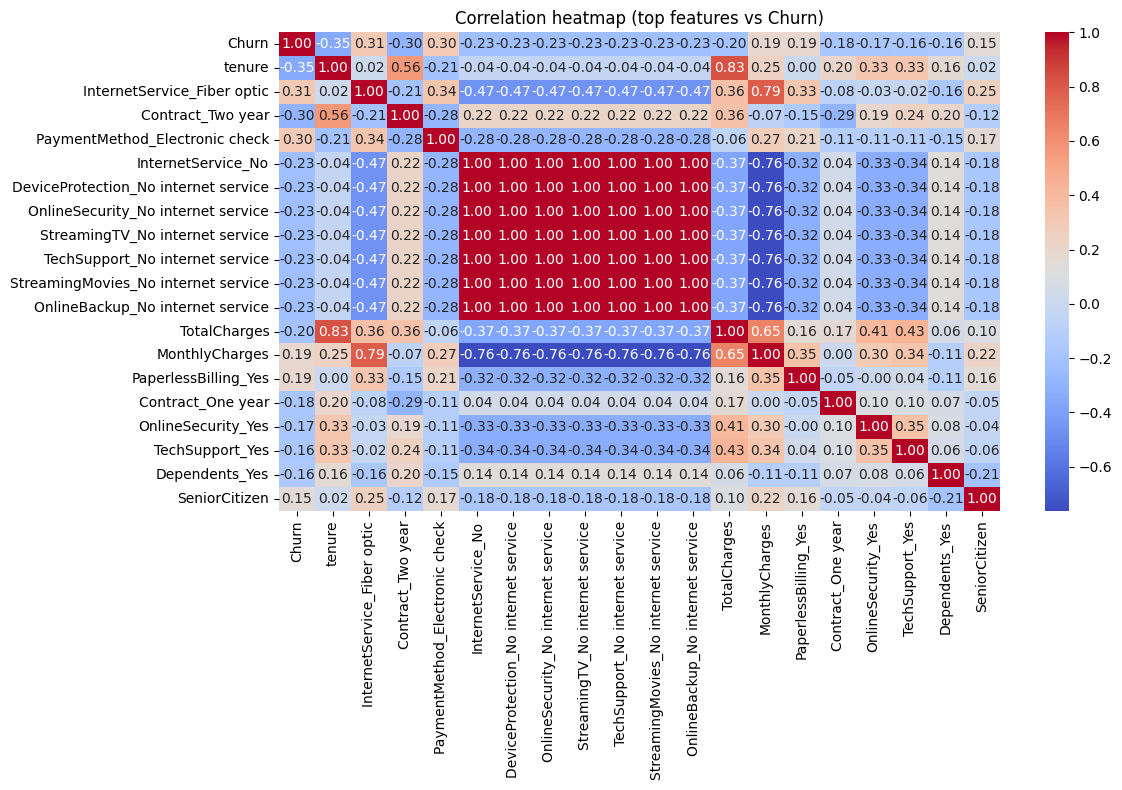

In [12]:
# Correlation plot with respect to Churn
plt.figure(figsize=(12,8))
# compute correlations with churn only (numeric columns)
corr_with_churn = telecom_cust_dummies.corr()['Churn'].sort_values(ascending=False)
print('\nTop correlations with Churn:')
print(corr_with_churn.head(15))

# I'll visualise a correlation heatmap for top features vs Churn
top_features = corr_with_churn.abs().sort_values(ascending=False).head(20).index.tolist()
plt_title = 'Correlation heatmap (top features vs Churn)'
sns.heatmap(telecom_cust_dummies[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title(plt_title)
plt.tight_layout()
plt.show()

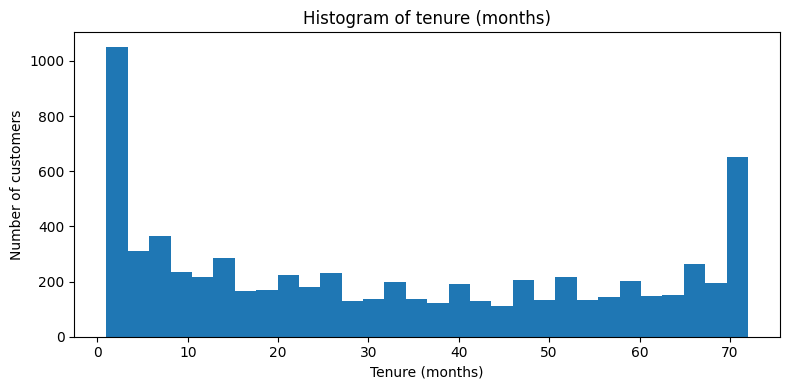

In [13]:
# Histogram of tenure
if 'tenure' in df.columns:
    plt.figure(figsize=(8,4))
    plt.hist(df['tenure'], bins=30)
    plt.title('Histogram of tenure (months)')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Number of customers')
    plt.tight_layout()
    plt.show()

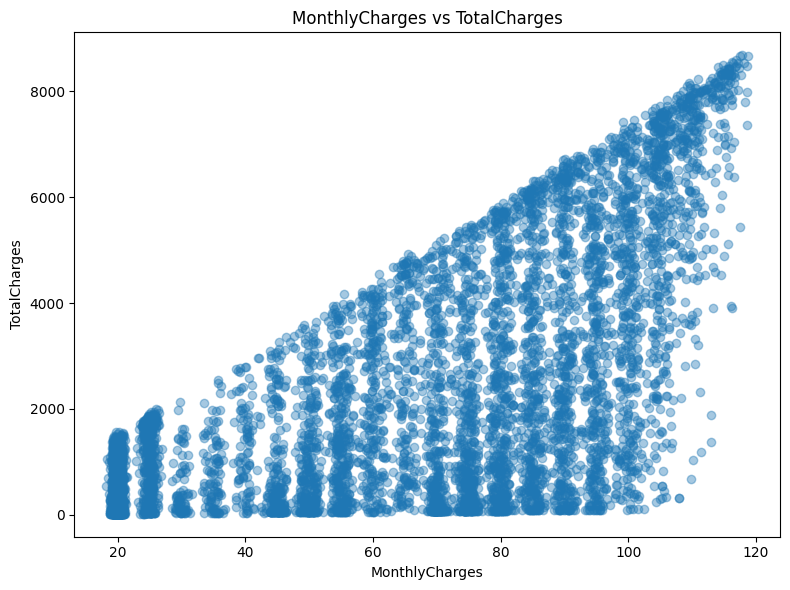

In [14]:
# Scatter plot MonthlyCharges vs TotalCharges
if set(['MonthlyCharges','TotalCharges']).issubset(df.columns):
    plt.figure(figsize=(8,6))
    plt.scatter(df['MonthlyCharges'], df['TotalCharges'], alpha=0.4)
    plt.title('MonthlyCharges vs TotalCharges')
    plt.xlabel('MonthlyCharges')
    plt.ylabel('TotalCharges')
    plt.tight_layout()
    plt.show()

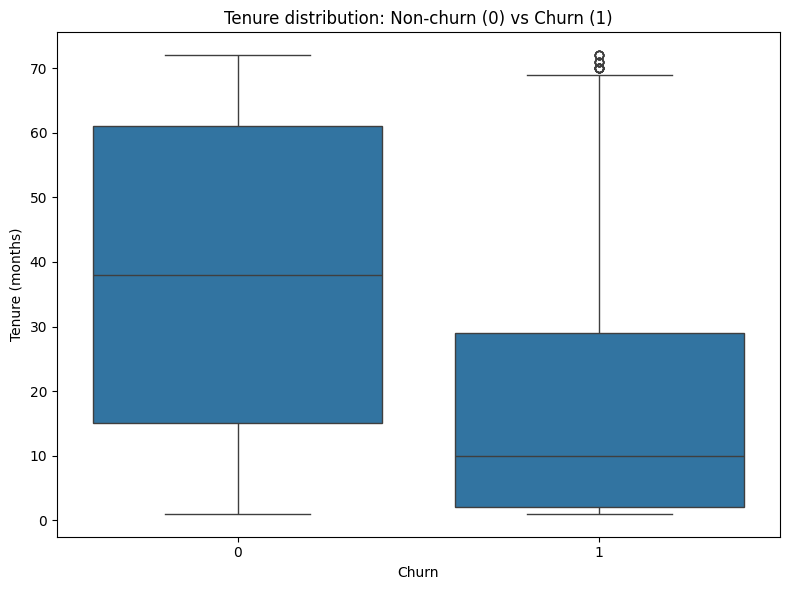

In [15]:
# Box plot to compare tenure for churned and non-churned customers
if set(['tenure','Churn']).issubset(telecom_cust_dummies.columns):
    plt.figure(figsize=(8,6))
    sns.boxplot(x='Churn', y='tenure', data=telecom_cust_dummies)
    plt.title('Tenure distribution: Non-churn (0) vs Churn (1)')
    plt.xlabel('Churn')
    plt.ylabel('Tenure (months)')
    plt.tight_layout()
    plt.show()

### Prepare for ML training: scaling and train-test split

In [16]:
# Separate target and features
if 'Churn' not in telecom_cust_dummies.columns:
    raise ValueError('Churn column not present after preprocessing. Did you map Churn correctly?')

X = telecom_cust_dummies.drop(columns=['Churn'])
y = telecom_cust_dummies['Churn']

# Min-max scaling to [0,1]
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)
print('\nTrain/Test sizes:', X_train.shape, X_test.shape)


Train/Test sizes: (5274, 30) (1758, 30)


### Logistic Regression model

In [18]:
# Logistic Regression model

logreg = LogisticRegression(max_iter=1000, solver='liblinear')
logreg.fit(X_train, y_train)

# Predictions
y_pred_log = logreg.predict(X_test)

# Accuracy
acc_log = accuracy_score(y_test, y_pred_log)
print(f'\nLogistic Regression Accuracy: {acc_log:.4f}')



Logistic Regression Accuracy: 0.8049


### Random Forest model with specified hyperparameters

In [19]:
# Random Forest model with specified hyperparameters

rf = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features='sqrt',
    max_leaf_nodes=50,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

# Fit model
rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf.predict(X_test)

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f}')

# OOB error estimation
if hasattr(rf, 'oob_score_'):
    oob_score = rf.oob_score_
    oob_error = 1 - oob_score
    print(f'Random Forest OOB score: {oob_score:.4f}')
    print(f'Random Forest OOB error (1 - oob_score): {oob_error:.4f}')
    print('\nInterpretation: OOB score approximates generalisation accuracy using the unused samples from bootstrapping. A small OOB error suggests the model generalises well; however this should be compared to test accuracy and cross-validation.')
else:
    print('OOB score not available for this RandomForest configuration.')

Random Forest Accuracy: 0.7918
Random Forest OOB score: 0.7992
Random Forest OOB error (1 - oob_score): 0.2008

Interpretation: OOB score approximates generalisation accuracy using the unused samples from bootstrapping. A small OOB error suggests the model generalises well; however this should be compared to test accuracy and cross-validation.


### Confusion matrix, precision and recall for both models

In [20]:
# Confusion matrix, precision and recall for both models

# Logistic
cm_log = confusion_matrix(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print('\nLogistic Regression - Confusion Matrix:\n', cm_log)
print(f'Precision: {precision_log:.4f}, Recall: {recall_log:.4f}')
print('\nRandom Forest - Confusion Matrix:\n', cm_rf)
print(f'Precision: {precision_rf:.4f}, Recall: {recall_rf:.4f}')


Logistic Regression - Confusion Matrix:
 [[1148  143]
 [ 200  267]]
Precision: 0.6512, Recall: 0.5717

Random Forest - Confusion Matrix:
 [[1174  117]
 [ 249  218]]
Precision: 0.6507, Recall: 0.4668


In [ ]:
# Discussion
print('\n--- Model performance discussion ---')
print('Confusion matrix layout: [[TN, FP], [FN, TP]]')
print('\nLogistic Regression:')
print(classification_report(y_test, y_pred_log, digits=4))

print('\nRandom Forest:')
print(classification_report(y_test, y_pred_rf, digits=4))

print('\nAnalysis:')
print('- Compare accuracy, precision, recall and the confusion matrices. Depending on business priorities (e.g., catching as many churners as possible), you may prefer the model with higher recall for class=1 (churn).')
print('- Precision indicates how many predicted churners actually churned (trade-off with recall).')
print('- If false negatives (missed churners) are costly, prioritise recall; if false positives (treating non-churners) are costly, prioritise precision.')



--- Model performance discussion ---
Confusion matrix layout: [[TN, FP], [FN, TP]]

Logistic Regression:
              precision    recall  f1-score   support

           0     0.8516    0.8892    0.8700      1291
           1     0.6512    0.5717    0.6089       467

    accuracy                         0.8049      1758
   macro avg     0.7514    0.7305    0.7395      1758
weighted avg     0.7984    0.8049    0.8007      1758


Random Forest:
              precision    recall  f1-score   support

           0     0.8250    0.9094    0.8651      1291
           1     0.6507    0.4668    0.5436       467

    accuracy                         0.7918      1758
   macro avg     0.7379    0.6881    0.7044      1758
weighted avg     0.7787    0.7918    0.7797      1758


Analysis:
- Compare accuracy, precision, recall and the confusion matrices. Depending on business priorities (e.g., catching as many churners as possible), you may prefer the model with higher recall for class=1 (churn).
- 

In [23]:
# Recommendation
print('\n--- Recommendation ---')
if recall_rf > recall_log and precision_rf >= precision_log:
    print('Random Forest has better recall and similar or better precision — likely the better choice if identifying churners is priority.')
elif recall_log > recall_rf and precision_log >= precision_rf:
    print('Logistic Regression shows better recall/precision balance — simpler and more interpretable, may be preferred if explanation is important.')
else:
    print('Metrics are mixed — consider business priorities. Random Forest often performs better in complex datasets; Logistic Regression is simpler and more explainable.')

print('\nYou can further improve models by:')
print('- Feature selection/engineering')
print('- Cross-validation and hyperparameter tuning (GridSearchCV/RandomizedSearchCV)')
print('- Calibrating classification threshold to balance precision/recall per business need')

# End of notebook
print('\nNotebook run complete.')



--- Recommendation ---
Logistic Regression shows better recall/precision balance — simpler and more interpretable, may be preferred if explanation is important.

You can further improve models by:
- Feature selection/engineering
- Cross-validation and hyperparameter tuning (GridSearchCV/RandomizedSearchCV)
- Calibrating classification threshold to balance precision/recall per business need

Notebook run complete.
